# Phase 3.5: Derived Metrics

Phases 0-4 (data audit/rebuild, feature engineering, deep EDA, statistical validation) are done.
This notebook builds five derived metrics that go beyond describing the data — they're
designed to be directly useful for Phase 5 modeling and Phase 6 business reporting
(`plan.md` §4).

**Ground rules (carried over from Phase 3/4):**
- Every metric that touches `Aggregate rating` runs on **`df_rated`** (`Is Rated`). Unrated
  restaurants have *no* rating to work with, not a rating of 0.
- **`Votes` is an evidence-strength / demand-proxy input in this notebook, never a rating
  predictor.** Phase 4 showed the raw votes→rating correlation is 89% an artifact of the
  unrated-as-zero encoding (0.296 → 0.031 once restricted to `df_rated`). Using vote count to
  decide *how much to trust* a rating (Bayesian shrinkage, §1) or *how much demand exists*
  (opportunity gaps, §5) is a different, legitimate use — each section says so explicitly.
- `Average Cost for two` and `Price range` are near-redundant (Spearman ρ = 0.83–0.91, `plan.md`
  §0.4). Each metric below picks one and states which.
- NCR is 91.95% of the data, and Phase 4 found the non-NCR sample skews small and popular
  (696 rows, curated-looking). Metrics involving geography or locality are scoped to NCR, or
  explicitly flagged when they aren't.

**Order in this notebook** (differs slightly from `plan.md` §4's listing order): credibility-
weighted rating is built first because it becomes the preferred "rating" input — instead of
raw `Aggregate rating` — for every metric downstream, so small-vote noise doesn't leak into
the value-for-money residual, the density-vs-rating check, or the cuisine-pair premium test.

1. Credibility-weighted (Bayesian shrinkage) rating
2. Value-for-money residual
3. Competition density (`BallTree`, haversine)
4. Cuisine co-occurrence
5. Locality opportunity gaps

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
from sklearn.neighbors import BallTree

# Chart styling: same editorial palette as Statistical_Validation.ipynb, plus one new
# accent (WARN) for this notebook's diverging/signed metrics (value-for-money residual,
# cuisine-pair premium, opportunity gaps) — nothing earlier needed a second hue.
ACCENT = '#2a78d6'
WARN = '#c1502e'
INK = '#0b0b0b'
INK_2 = '#52514e'
MUTED = '#898781'
GRID = '#e1e0d9'
AXIS = '#c3c2b7'
SURFACE = '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 1, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlecolor': INK,
})

In [2]:
# Output/ CSVs are written by pandas as UTF-8 (only the raw zomato.csv needs latin-1)
df = pd.read_csv('Output/df_featured.csv')
df_rated = df[df['Is Rated']].copy()

RATING = 'Aggregate rating'
ALPHA = 0.05

print(f"All rows: {len(df):,} | Rated rows (df_rated): {len(df_rated):,} | Unrated rows: {(~df['Is Rated']).sum():,}")
print(f"Rating range on df_rated: {df_rated[RATING].min()} - {df_rated[RATING].max()}")

All rows: 8,643 | Rated rows (df_rated): 6,504 | Unrated rows: 2,139
Rating range on df_rated: 1.8 - 4.9


### Observation:
8,643 total restaurants split into 6,504 rated / 2,139 unrated — identical to every earlier
notebook's split, confirming `df_featured.csv` loaded cleanly. Rated restaurants range from
1.8 to 4.9 (never as low as 0, which is exactly the "unrated ≠ rated zero" fix from Phase 2).

## 1. Credibility-weighted (Bayesian shrinkage) rating

A 4.9 rating from 5 votes and a 4.7 from 5,000 votes are not equally trustworthy. Shrink each restaurant's rating toward the global mean by an amount that depends on how little evidence (votes) it has: `Cred_Rating = (v·R + m·C) / (v + m)`, where `v` = votes, `R` = raw rating, `C` = global mean rating, `m` = a vote-count threshold. Runs on `df_rated` only — unrated restaurants have no `R` to shrink (that's the separate Phase 5B cold-start problem).

In [3]:
# m = median vote count on df_rated, not the mean: Votes is heavily right-skewed (the same
# reasoning that motivated Log_Votes), so the mean would be dragged by a few very popular
# chains into an unrealistically large prior strength.
C = df_rated[RATING].mean()
m = df_rated['Votes'].median()
below_m = (df_rated['Votes'] < m).sum()

print(f"C (global mean rating) = {C:.4f}")
print(f"m (median vote count)  = {m:.0f}")
print(f"Restaurants with Votes < m: {below_m:,} ({below_m/len(df_rated):.1%}) -- these get meaningfully shrunk toward C")

C (global mean rating) = 3.3513
m (median vote count)  = 49
Restaurants with Votes < m: 3,216 (49.4%) -- these get meaningfully shrunk toward C


### Observation:
Global mean rating `C = 3.3513` and median vote count `m = 49`. Nearly half the rated
restaurants (3,216, 49.4%) have fewer than 49 votes, so shrinkage will move a meaningful chunk
of the dataset, not just a handful of extreme cases.

In [4]:
v = df_rated['Votes']
R = df_rated[RATING]
df_rated['Cred_Rating'] = (v * R + m * C) / (v + m)
df_rated['shrinkage_weight'] = m / (v + m)

print(df_rated[['Restaurant Name', 'Votes', RATING, 'Cred_Rating', 'shrinkage_weight']].sample(5, random_state=42).to_string(index=False))
print(f"\nCred_Rating range: {df_rated['Cred_Rating'].min():.3f} - {df_rated['Cred_Rating'].max():.3f}")

               Restaurant Name  Votes  Aggregate rating  Cred_Rating  shrinkage_weight
                    Nawab Dera    141               3.8     3.684276          0.257895
                 Trending Eats     21               3.4     3.365893          0.700000
                   Ginnis Oven      9               3.2     3.327802          0.844828
The Punjabi Essence Restaurant    102               3.6     3.519288          0.324503
                    Ooh Lala !    154               4.0     3.843411          0.241379

Cred_Rating range: 2.005 - 4.887


### Observation:
`Cred_Rating` compresses the range from the raw 1.8–4.9 down to 2.005–4.887 — both tails pull
toward the mean. The five-restaurant sample shows the mechanic directly: `Ginnis Oven` (9
votes, `shrinkage_weight` = 0.84) moves from 3.2 to 3.33, while `Nawab Dera` (141 votes, weight
0.26) barely moves (3.8 → 3.68).

In [5]:
df_rated['rank_raw'] = df_rated[RATING].rank(ascending=False, method='min')
df_rated['rank_cred'] = df_rated['Cred_Rating'].rank(ascending=False, method='min')
df_rated['rank_change'] = df_rated['rank_raw'] - df_rated['rank_cred']

top15_raw = df_rated.nlargest(15, RATING)[['Restaurant Name', 'Votes', RATING, 'Cred_Rating']]
top15_cred = df_rated.nlargest(15, 'Cred_Rating')[['Restaurant Name', 'Votes', RATING, 'Cred_Rating']]

dropped_out = set(top15_raw['Restaurant Name']) - set(top15_cred['Restaurant Name'])
entered = set(top15_cred['Restaurant Name']) - set(top15_raw['Restaurant Name'])

print("Top 15 by raw rating:")
print(top15_raw.to_string(index=False))
print("\nTop 15 by Cred_Rating:")
print(top15_cred.to_string(index=False))
print(f"\nDropped out of top 15 (raw -> cred): {sorted(dropped_out)}")
print(f"Entered top 15 (raw -> cred): {sorted(entered)}")

Top 15 by raw rating:
              Restaurant Name  Votes  Aggregate rating  Cred_Rating
        Sagar Gaire Fast Food    427               4.9     4.740573
    AB's - Absolute Barbecues    859               4.9     4.816423
                      CakeBee    200               4.9     4.595231
         The Great Indian Pub     50               4.9     4.133460
                  Caterspoint    223               4.9     4.621002
              Barbeque Nation    774               4.9     4.807792
    AB's - Absolute Barbecues    200               4.9     4.595231
    AB's - Absolute Barbecues   5434               4.9     4.886159
Zolocrust - Hotel Clarks Amer    322               4.9     4.695452
              Barbeque Nation   1753               4.9     4.857887
              Barbeque Nation   5966               4.9     4.887384
    Grandson of Tunday Kababi   1057               4.9     4.831386
              Mirchi And Mime   3244               4.9     4.876955
              Barbeque Nat

### Observation:
Four restaurants drop out of the raw top 15 once vote count is accounted for — `CakeBee`,
`Caterspoint`, `The Great Indian Pub` and `Zolocrust - Hotel Clarks Amer` — all sitting on a
4.9 built from 200–322 votes. Six restaurants with high-vote 4.8–4.9 ratings take their place:
`Chili's`, `Indian Accent - The Manor`, `Le Plaisir`, `Prankster`, `Spice Kraft`, `Toit`. The
raw top 15 also has three chains repeated 2–3 times each (`Barbeque Nation`, `AB's - Absolute
Barbecues`) with wildly different vote counts (50 to 5,966) all tied at 4.9 — exactly the kind
of noise `Cred_Rating` is meant to separate. After shrinkage, `Barbeque Nation`'s 5,966-vote
outlet (Cred 4.887) and `AB's` 5,434-vote outlet (Cred 4.886) lead outright, ahead of every
low-vote 4.9.

In [6]:
# Robustness check: does the re-ranking depend heavily on the specific choice of m?
m_q1 = df_rated['Votes'].quantile(0.25)
m_q3 = df_rated['Votes'].quantile(0.75)

def cred_rating_at(m_val):
    return (v * R + m_val * C) / (v + m_val)

top15_q1 = set(df_rated.assign(cr=cred_rating_at(m_q1)).nlargest(15, 'cr')['Restaurant Name'])
top15_q3 = set(df_rated.assign(cr=cred_rating_at(m_q3)).nlargest(15, 'cr')['Restaurant Name'])
top15_primary = set(top15_cred['Restaurant Name'])

print(f"m = Q1 ({m_q1:.0f}): overlap with primary (m={m:.0f}) top 15 = {len(top15_primary & top15_q1)}/15")
print(f"m = Q3 ({m_q3:.0f}): overlap with primary (m={m:.0f}) top 15 = {len(top15_primary & top15_q3)}/15")

m = Q1 (16): overlap with primary (m=49) top 15 = 8/15
m = Q3 (149): overlap with primary (m=49) top 15 = 11/15


### Observation:
Robustness holds directionally but isn't insensitive to `m`: the primary top 15 (m=49) overlaps
8/15 with `m` at Q1 (16 votes) and 11/15 with `m` at Q3 (149 votes) — a smaller `m` shrinks less
and lets more low-vote restaurants back into the top 15, a larger `m` shrinks harder and
converges toward the pure-high-vote ranking. The overlap is well above chance in both
directions, so the choice of `m` shifts degree, not direction, of the re-ranking.

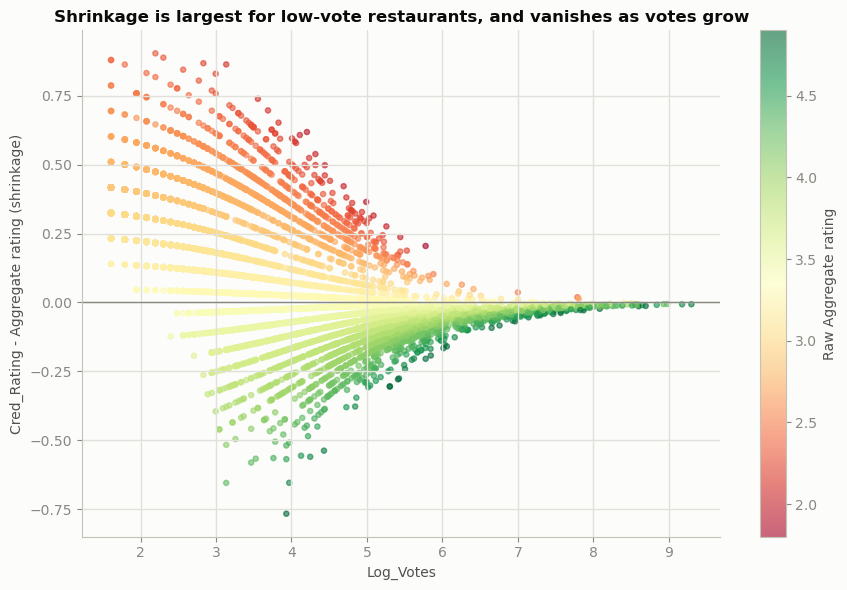

In [7]:
shrinkage_amt = df_rated['Cred_Rating'] - df_rated[RATING]
plt.figure(figsize=(9, 6))
sc = plt.scatter(df_rated['Log_Votes'], shrinkage_amt, c=df_rated[RATING], cmap='RdYlGn', s=14, alpha=0.6)
plt.colorbar(sc, label='Raw Aggregate rating')
plt.axhline(0, color=MUTED, linewidth=1)
plt.xlabel('Log_Votes')
plt.ylabel('Cred_Rating - Aggregate rating (shrinkage)')
plt.title('Shrinkage is largest for low-vote restaurants, and vanishes as votes grow')
plt.tight_layout()
plt.show()

### Observation:
Shrinkage is largest (up to nearly a full point) at low `Log_Votes` and decays toward zero as
`Log_Votes` grows, exactly as the formula guarantees — the scatter has no low-vote points near
zero shrinkage, confirming no restaurant escapes the correction just because its raw rating
happens to be high.

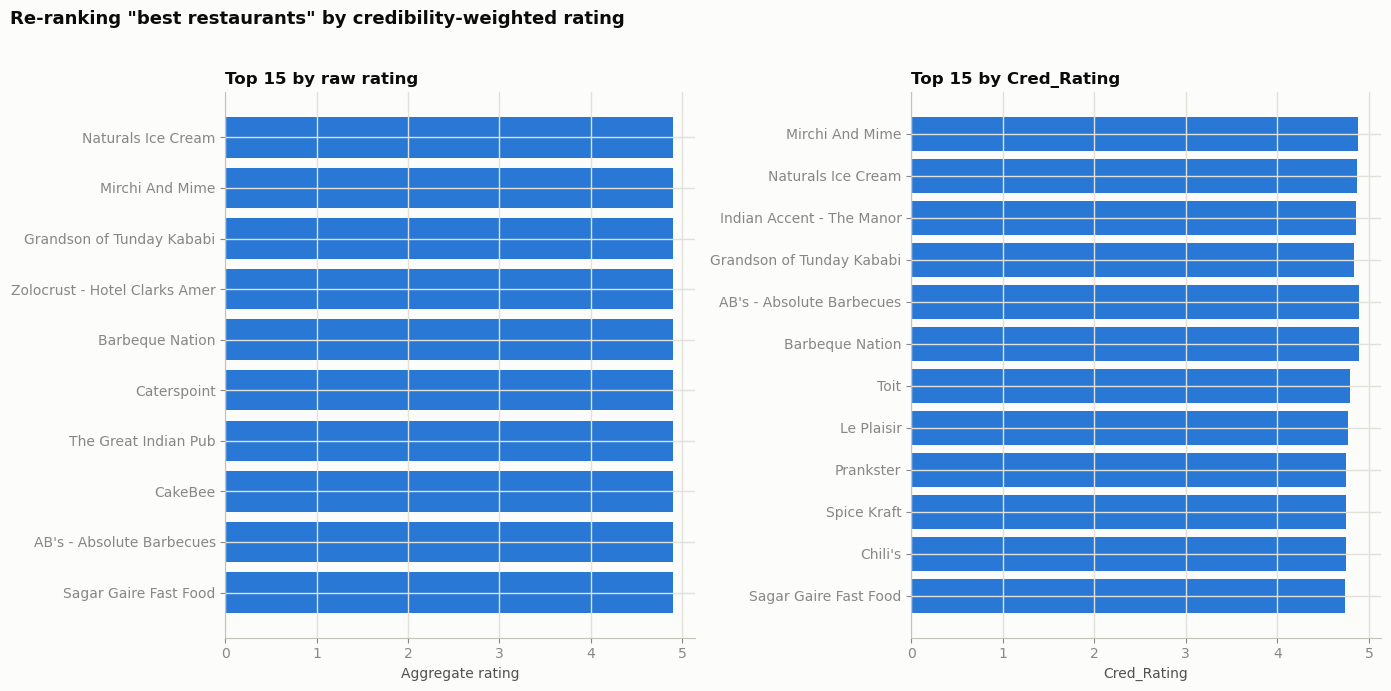

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=False)
for ax, data, title, col in zip(axes, [top15_raw, top15_cred],
                                 ['Top 15 by raw rating', 'Top 15 by Cred_Rating'],
                                 [RATING, 'Cred_Rating']):
    data_sorted = data.sort_values(col)
    ax.barh(data_sorted['Restaurant Name'], data_sorted[col], color=ACCENT)
    ax.set_title(title, loc='left')
    ax.set_xlabel(col)
fig.suptitle('Re-ranking "best restaurants" by credibility-weighted rating', x=0.01, ha='left', fontsize=13, fontweight='semibold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Observation:
The two panels make the re-ranking from the cell above visible at a glance: the raw-rating
panel is dominated by several restaurants tied at 4.9 regardless of vote count, while the
`Cred_Rating` panel orders them by a mix of rating and evidence — the highest bars are now the
highest-vote 4.9s, not an arbitrary tie.

In [9]:
os.makedirs('Output', exist_ok=True)
out_cols_cred = ['Restaurant ID', 'Restaurant Name', 'Votes', RATING, 'Cred_Rating',
                 'shrinkage_weight', 'rank_raw', 'rank_cred', 'rank_change']
df_rated[out_cols_cred].to_csv('Output/credibility_weighted_ratings.csv', index=False)
print("Saved Output/credibility_weighted_ratings.csv:", df_rated[out_cols_cred].shape)

Saved Output/credibility_weighted_ratings.csv: (6504, 9)


### Observation:
Saved all 6,504 rated restaurants (not just the top 15) to
`Output/credibility_weighted_ratings.csv`, so Phase 5/6 can use `Cred_Rating` as an alternative
modeling target or ranking metric for any restaurant, not only the ones shown above.

## 2. Value-for-money residual

Regress `Cred_Rating` on cost, then rank restaurants by the residual: positive residual = rated higher than its cost predicts (over-delivers), negative = over-priced for what it delivers. Uses `Cred_Rating` (§1), not raw `Aggregate rating`, so a restaurant with 5 votes and a lucky 4.9 can't register as a huge "over-performer." Predictor is `Log_Cost` (continuous), not `Price range` (only 4 buckets — too coarse for a ranked residual, and redundant with cost anyway).

In [10]:
df_rated['Log_Cost'] = np.log1p(df_rated['Average Cost for two'])
ncr_mask = df_rated['Is NCR']

# Fit separately within NCR and outside NCR -- not one pooled model. Pooling would let the
# small, curated non-NCR sample (696 rows, Phase 4 sec 5.1) distort the fit for the other
# 92% of the data, echoing the table-booking Simpson's-paradox trap Phase 4 already found.
results_vfm = {}
for label, mask in [('NCR', ncr_mask), ('Non-NCR', ~ncr_mask)]:
    sub = df_rated[mask]
    slope, intercept, r, p, se = stats.linregress(sub['Log_Cost'], sub['Cred_Rating'])
    results_vfm[label] = dict(slope=slope, intercept=intercept, r2=r**2, p=p, n=len(sub))
    print(f"{label}: n={len(sub):,}, slope={slope:.4f}, intercept={intercept:.4f}, r^2={r**2:.4f}, p={p:.3g}")

NCR: n=5,808, slope=0.0986, intercept=2.7704, r^2=0.0620, p=9.66e-83
Non-NCR: n=696, slope=0.2096, intercept=2.4501, r^2=0.0968, p=4.3e-17


### Observation:
Both fits are significant but weak: NCR r² = 0.062 (n = 5,808), Non-NCR r² = 0.097 (n = 696).
Taking the square root (≈0.25 and ≈0.31) lines up with Phase 3's cost-rating Pearson
correlation (~0.31) — this residual isn't manufacturing a strong cost-rating trend out of
nothing, it's honestly small, consistent with earlier findings. The non-NCR slope (0.21) is
roughly double the NCR slope (0.10): cost predicts rating a bit more strongly outside NCR, but
per Phase 4 that sample is small and skews toward already-popular restaurants, so this
difference itself carries the same sampling caveat.

In [11]:
df_rated['Predicted_Rating'] = np.where(
    ncr_mask,
    results_vfm['NCR']['slope'] * df_rated['Log_Cost'] + results_vfm['NCR']['intercept'],
    results_vfm['Non-NCR']['slope'] * df_rated['Log_Cost'] + results_vfm['Non-NCR']['intercept'],
)
df_rated['Residual'] = df_rated['Cred_Rating'] - df_rated['Predicted_Rating']

print(df_rated.groupby('Is NCR')['Residual'].agg(['mean', 'std', 'min', 'max']).round(4))

        mean     std     min     max
Is NCR                              
False    0.0  0.3558 -1.2850  1.1853
True     0.0  0.2789 -1.4469  1.6063


### Observation:
Residuals average exactly 0 within each group by construction. Non-NCR residuals spread wider
(std 0.356, range -1.285 to 1.185) than NCR's (std 0.279, range -1.447 to 1.606) — NCR's larger
maximum comes from its much bigger sample giving more room for an extreme outlier, not from a
systematically worse fit.

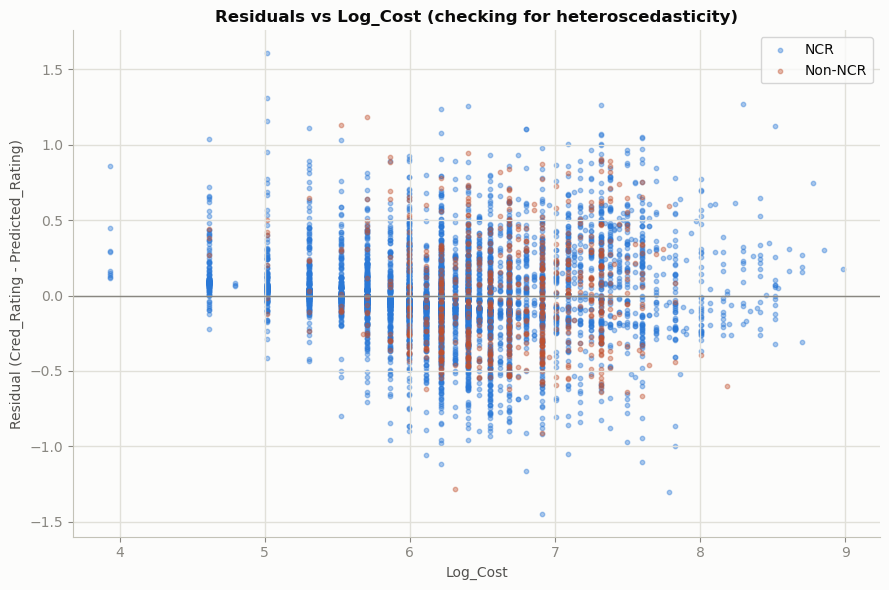

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
for label, mask, color in [('NCR', ncr_mask, ACCENT), ('Non-NCR', ~ncr_mask, WARN)]:
    ax.scatter(df_rated.loc[mask, 'Log_Cost'], df_rated.loc[mask, 'Residual'], s=10, alpha=0.4, color=color, label=label)
ax.axhline(0, color=MUTED, linewidth=1)
ax.legend()
ax.set_xlabel('Log_Cost')
ax.set_ylabel('Residual (Cred_Rating - Predicted_Rating)')
ax.set_title('Residuals vs Log_Cost (checking for heteroscedasticity)')
plt.tight_layout()
plt.show()

### Observation:
Residual spread looks broadly even across the `Log_Cost` range in both groups, with no strong
funnel shape — no correction for heteroscedasticity is needed before ranking by residual.

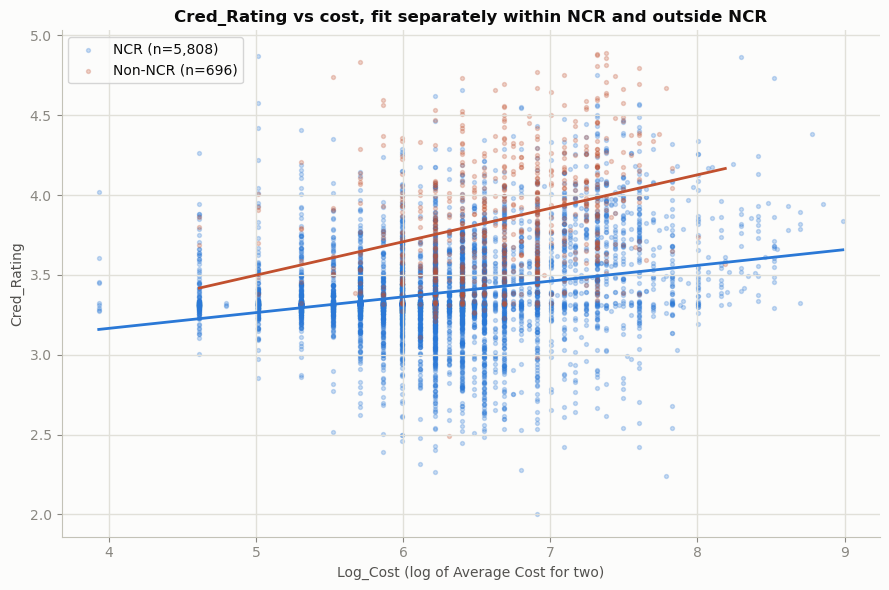

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
xs_ncr = np.linspace(df_rated.loc[ncr_mask, 'Log_Cost'].min(), df_rated.loc[ncr_mask, 'Log_Cost'].max(), 100)
xs_non = np.linspace(df_rated.loc[~ncr_mask, 'Log_Cost'].min(), df_rated.loc[~ncr_mask, 'Log_Cost'].max(), 100)
for label, mask, color, xs in [('NCR', ncr_mask, ACCENT, xs_ncr), ('Non-NCR', ~ncr_mask, WARN, xs_non)]:
    ax.scatter(df_rated.loc[mask, 'Log_Cost'], df_rated.loc[mask, 'Cred_Rating'], s=8, alpha=0.25, color=color,
               label=f'{label} (n={mask.sum():,})')
    r = results_vfm[label]
    ax.plot(xs, r['slope'] * xs + r['intercept'], color=color, linewidth=2)
ax.legend()
ax.set_xlabel('Log_Cost (log of Average Cost for two)')
ax.set_ylabel('Cred_Rating')
ax.set_title('Cred_Rating vs cost, fit separately within NCR and outside NCR')
plt.tight_layout()
plt.show()

### Observation:
The non-NCR fitted line (steeper) and NCR line (flatter) diverge visibly at higher cost, which
is the r²/slope difference from the regression cell made visual — both lines sit inside a wide,
noisy cloud of points, another way of seeing that cost alone explains only a small share of
`Cred_Rating`.

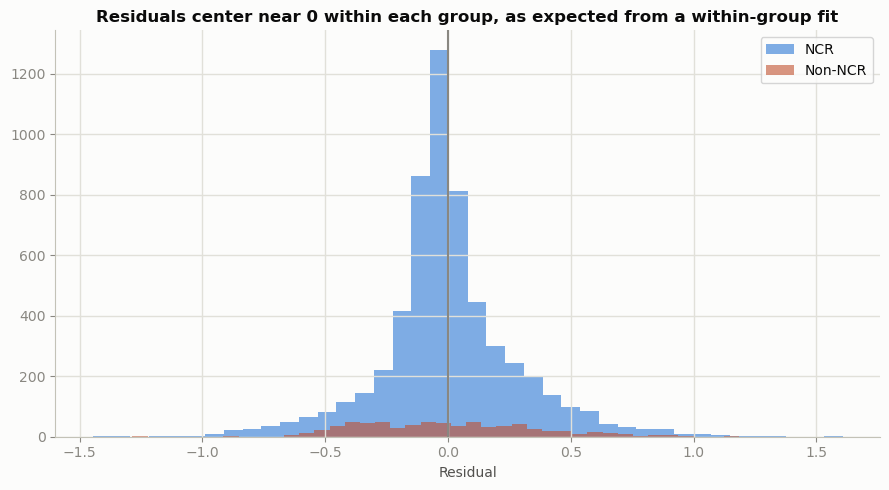

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(df_rated.loc[ncr_mask, 'Residual'], bins=40, alpha=0.6, color=ACCENT, label='NCR')
plt.hist(df_rated.loc[~ncr_mask, 'Residual'], bins=40, alpha=0.6, color=WARN, label='Non-NCR')
plt.axvline(0, color=MUTED)
plt.legend()
plt.xlabel('Residual')
plt.title('Residuals center near 0 within each group, as expected from a within-group fit')
plt.tight_layout()
plt.show()

### Observation:
Both histograms center on 0 as expected, with the NCR distribution taller/narrower (more rows,
tighter std) and the non-NCR one flatter/wider — matching the std figures from two cells above.

In [15]:
top15_over = df_rated.nlargest(15, 'Residual')[
    ['Restaurant Name', 'Locality', 'Is NCR', 'Average Cost for two', RATING, 'Cred_Rating', 'Residual']]
top15_under = df_rated.nsmallest(15, 'Residual')[
    ['Restaurant Name', 'Locality', 'Is NCR', 'Average Cost for two', RATING, 'Cred_Rating', 'Residual']]

print("Top 15 over-performers (best value for money):")
print(top15_over.to_string(index=False))
print("\nTop 15 under-performers (worst value for money):")
print(top15_under.to_string(index=False))

Top 15 over-performers (best value for money):
             Restaurant Name                           Locality  Is NCR  Average Cost for two  Aggregate rating  Cred_Rating  Residual
          Naturals Ice Cream                    Connaught Place    True                   150               4.9     4.871567  1.606336
          Naturals Ice Cream                     Rajouri Garden    True                   150               4.7     4.573638  1.308407
   Indian Accent - The Manor                     Friends Colony    True                  4000               4.9     4.861731  1.273287
                   Prankster                          Sector 29    True                  1500               4.8     4.753512  1.261766
         Echoes Satyaniketan                       Satyaniketan    True                   600               4.7     4.659003  1.257532
                 Caterspoint                        DLF Phase 3    True                   500               4.9     4.621002  1.237481
   Grand

### Observation:
The best value-for-money restaurant is `Naturals Ice Cream` at Connaught Place (₹150, Cred
4.87, residual +1.61) — a very cheap outlet massively over-delivering on quality. The worst is
`Pind Balluchi` at Shipra Mall (₹1,000, Cred 2.00, residual -1.45). A striking pattern in the
under-performers: three of the bottom 15 (`Club Ice Cube`, `Chopaal`, `Moti Mahal Delux
Tandoori Trail`) all sit in the same mall — The Great India Place, Sector 38 — suggesting a
specific under-performing mall food-court cluster rather than a scattered coincidence. Chain
fast-food (`KFC`, two `Subway` outlets) also shows up among the worst residuals, at moderate
cost with low ratings.

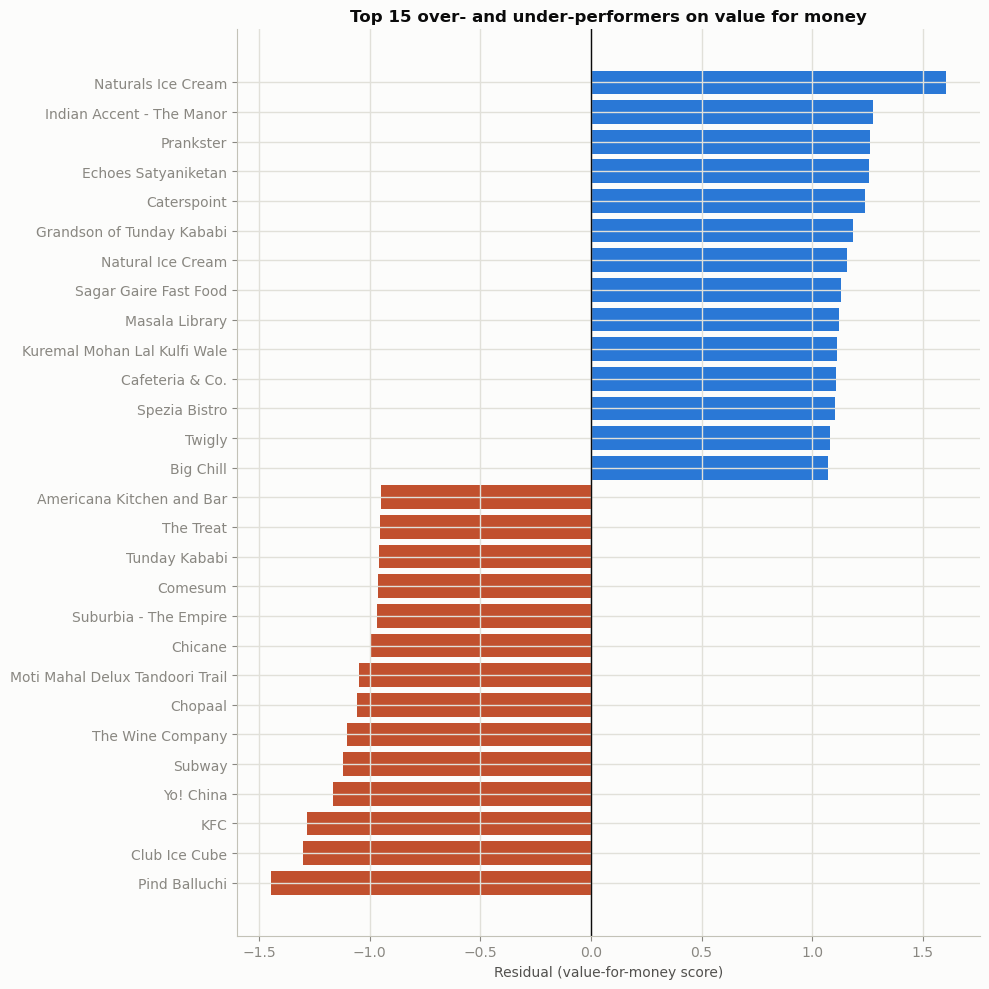

In [16]:
combo = pd.concat([top15_over.assign(group='Over-delivers'), top15_under.assign(group='Over-priced')])
combo_sorted = combo.sort_values('Residual')
colors = [ACCENT if x > 0 else WARN for x in combo_sorted['Residual']]

plt.figure(figsize=(10, 10))
plt.barh(combo_sorted['Restaurant Name'], combo_sorted['Residual'], color=colors)
plt.axvline(0, color=INK, linewidth=1)
plt.xlabel('Residual (value-for-money score)')
plt.title('Top 15 over- and under-performers on value for money')
plt.tight_layout()
plt.show()

### Observation:
The diverging bars make the mall-cluster pattern and the cheap-and-excellent pattern easy to
compare side by side: over-performers (ACCENT) skew toward inexpensive standalone spots,
under-performers (WARN) skew toward mid-to-high-cost mall/chain locations.

In [17]:
df_rated['rank_overall'] = df_rated['Residual'].rank(ascending=False, method='min')
df_rated['rank_within_ncr_group'] = df_rated.groupby('Is NCR')['Residual'].rank(ascending=False, method='min')

out_cols_vfm = ['Restaurant ID', 'Restaurant Name', 'Locality', 'Is NCR', 'Average Cost for two', 'Log_Cost',
                RATING, 'Cred_Rating', 'Predicted_Rating', 'Residual', 'rank_overall', 'rank_within_ncr_group']
df_rated[out_cols_vfm].to_csv('Output/value_for_money_residuals.csv', index=False)
print("Saved Output/value_for_money_residuals.csv:", df_rated[out_cols_vfm].shape)

Saved Output/value_for_money_residuals.csv: (6504, 12)


### Observation:
Saved all 6,504 rated restaurants with their residual and both rank columns to
`Output/value_for_money_residuals.csv` — usable directly as a Phase 6 "best value" /
"overpriced" business narrative, or as a Phase 5 engineered feature.

## 3. Competition density (`BallTree`, haversine)

For each NCR restaurant, count how many other restaurants sit within a fixed radius, using `sklearn.neighbors.BallTree` with the haversine metric. Built over **all** NCR restaurants with valid coordinates — rated and unrated together — since physical competition exists whether or not Zomato has collected a rating yet. Restricted to NCR only: non-NCR coordinate coverage isn't verified (only NCR's 98% figure is, from `Deep_EDA.ipynb`).

In [18]:
# Filter Latitude/Longitude != 0 BEFORE building the tree: two restaurants both missing GPS
# both sit at (0, 0) ("Null Island") and would register as 0km apart, inflating density for
# every row with missing coordinates -- a correctness bug, not a cosmetic filter.
coords_df = df[(df['Is NCR']) & (df['Latitude'] != 0) & (df['Longitude'] != 0)].copy()
print(f"NCR restaurants with valid GPS: {len(coords_df):,} of {df['Is NCR'].sum():,} total NCR rows")

coords_rad = np.radians(coords_df[['Latitude', 'Longitude']].values)
tree = BallTree(coords_rad, metric='haversine')

EARTH_RADIUS_KM = 6371.0
for radius_km, col in [(0.5, 'Competitors_500m'), (1.0, 'Competitors_1km'), (2.0, 'Competitors_2km')]:
    counts = tree.query_radius(coords_rad, r=radius_km / EARTH_RADIUS_KM, count_only=True) - 1  # exclude self
    coords_df[col] = counts

print(coords_df[['Competitors_500m', 'Competitors_1km', 'Competitors_2km']].describe())

NCR restaurants with valid GPS: 7,550 of 7,947 total NCR rows


       Competitors_500m  Competitors_1km  Competitors_2km
count       7550.000000      7550.000000      7550.000000
mean          30.241325        68.027020       179.502781
std           26.249282        45.439894        97.004977
min            0.000000         0.000000         0.000000
25%           11.000000        32.000000       102.000000
50%           24.000000        59.000000       168.000000
75%           42.000000        95.000000       265.000000
max          165.000000       225.000000       394.000000


### Observation:
7,550 of 7,947 total NCR restaurants (95.0%) have usable coordinates — slightly below the
98% figure `Deep_EDA.ipynb` found for *rated* NCR restaurants alone, meaning unrated NCR
restaurants have marginally worse GPS coverage, but the tree is still built on a highly
representative sample either way. The distribution is heavily right-skewed and dense: a
typical restaurant has 59 competitors within 1km (median), and some have as many as 225 — NCR
restaurants cluster tightly rather than spreading out.

In [19]:
bins = [-1, 0, 5, 20, np.inf]
labels = ['Isolated (0)', 'Light (1-5)', 'Moderate (6-20)', 'Dense (20+)']
coords_df['density_tier'] = pd.cut(coords_df['Competitors_1km'], bins=bins, labels=labels)

merged = coords_df.merge(df_rated[['Restaurant ID', 'Cred_Rating']], on='Restaurant ID', how='inner')
print(f"Merged onto df_rated: {len(merged):,} rows")

rho_rating, p_rating = stats.spearmanr(merged['Competitors_1km'], merged['Cred_Rating'])
rho_cost, p_cost = stats.spearmanr(merged['Competitors_1km'], merged['Average Cost for two'])
print(f"Spearman(Competitors_1km, Cred_Rating) = {rho_rating:.4f}, p={p_rating:.3g}")
print(f"Spearman(Competitors_1km, cost) = {rho_cost:.4f}, p={p_cost:.3g}")
print()
print(merged.groupby('density_tier', observed=True)[['Cred_Rating', 'Average Cost for two']].mean().round(3))

Merged onto df_rated: 5,695 rows
Spearman(Competitors_1km, Cred_Rating) = 0.1834, p=2.78e-44
Spearman(Competitors_1km, cost) = 0.1028, p=7.24e-15

                 Cred_Rating  Average Cost for two
density_tier                                      
Isolated (0)           3.444               581.250
Light (1-5)            3.354               773.469
Moderate (6-20)        3.341               668.719
Dense (20+)            3.392               701.158


### Observation:
Density correlates only weakly with both rating (Spearman ρ = 0.183) and cost (ρ = 0.103) —
present and significant at this sample size (n = 5,695) but small. The tier means are
**non-monotonic**: isolated restaurants (0 competitors within 1km) actually average the
*highest* rating (3.444), light and moderate density dip lower (3.354, 3.341), and dense areas
partially recover (3.392). Competition density neither cleanly suppresses nor boosts rating on
its own — isolated restaurants look like they include genuine local destinations that don't
need nearby competition to sustain demand, which is exactly the kind of finding a raw scatter
plot (`Deep_EDA.ipynb` cell 43) couldn't have surfaced.

Price range          1      2      3      4
density_tier                               
Isolated (0)     3.425  3.497  3.365    NaN
Light (1-5)      3.338  3.279  3.700  3.333
Moderate (6-20)  3.331  3.311  3.339  3.648
Dense (20+)      3.342  3.352  3.574  3.626


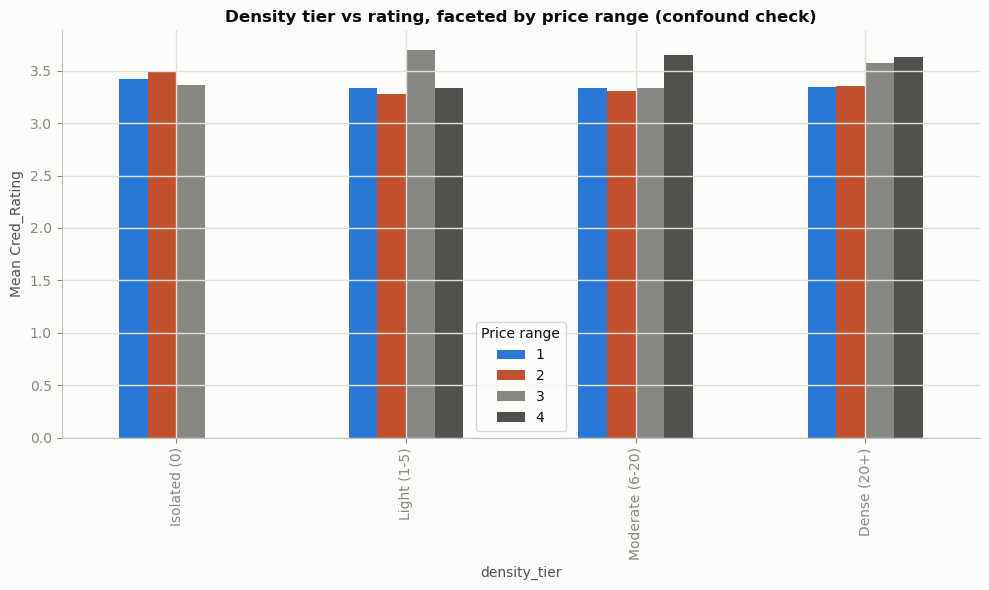

In [20]:
# Confound check: dense commercial areas plausibly correlate with cost independent of any
# density-suppresses-rating effect -- the same Simpson's-paradox risk Phase 4 already taught
# with table booking. Facet the density-tier-vs-rating relationship by price range.
tier_price = merged.groupby(['density_tier', 'Price range'], observed=True)['Cred_Rating'].mean().unstack()
print(tier_price.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
tier_price.plot(kind='bar', ax=ax, color=[ACCENT, WARN, MUTED, INK_2])
ax.set_ylabel('Mean Cred_Rating')
ax.set_title('Density tier vs rating, faceted by price range (confound check)')
ax.legend(title='Price range')
plt.tight_layout()
plt.show()

### Observation:
The confound check changes the story. Within price range 1, density barely matters (3.42 vs
3.34 vs 3.33 vs 3.34 — essentially flat). But at price ranges 3–4, dense and moderate-density
areas actually rate *higher* than light-density ones (range 4: light 3.333 vs moderate 3.648 vs
dense 3.626) — the opposite direction of the raw isolated-restaurants-win pattern. And there
are **no isolated (0-competitor) restaurants at price range 4 at all** (NaN cell) — in this
data, every premium restaurant has neighbors within 1km, which makes geographic sense (NCR's
premium dining sits in commercial hubs, not empty pockets). So "isolated restaurants rate
best" from the raw tier means is largely a budget-tier (range 1–2) pattern; at the premium end,
density and quality actually go together.

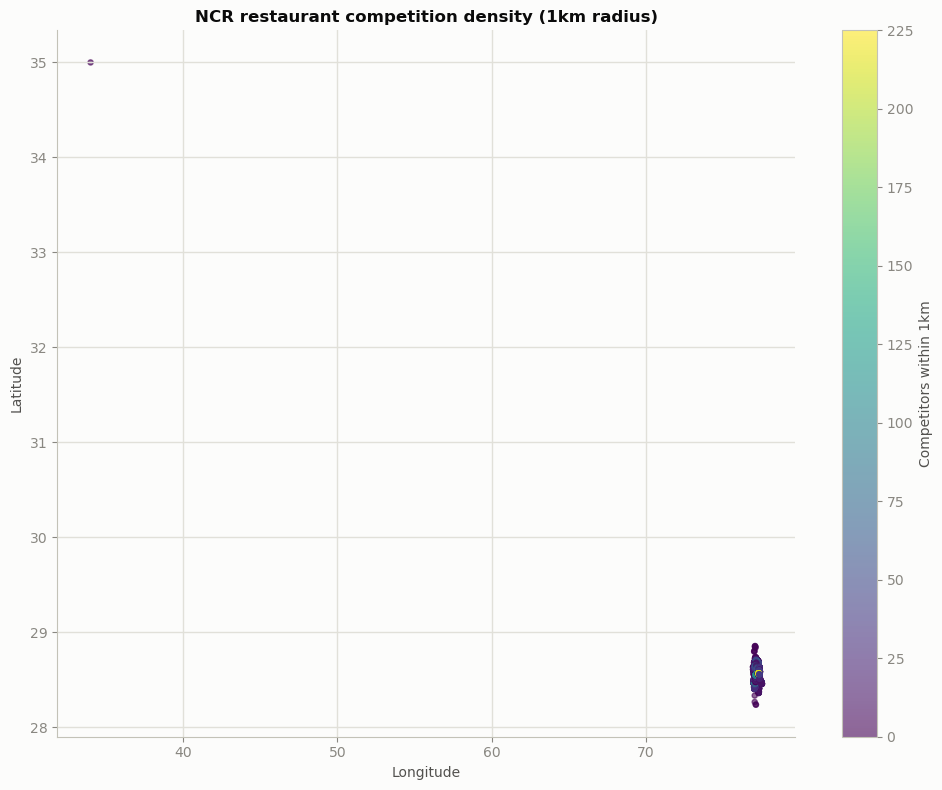

In [21]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(coords_df['Longitude'], coords_df['Latitude'], c=coords_df['Competitors_1km'],
                  cmap='viridis', s=14, alpha=0.6)
plt.colorbar(sc, label='Competitors within 1km')
plt.title('NCR restaurant competition density (1km radius)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### Observation:
The map shows the same tight clustering seen in the summary statistics — dense yellow/green
(high-`viridis`) hotspots concentrate in a handful of commercial pockets, with sparser
(dark-`viridis`) areas at the map's edges, consistent with NCR's known locality concentration
(a handful of localities carry most of the restaurant volume, per Phase 3).

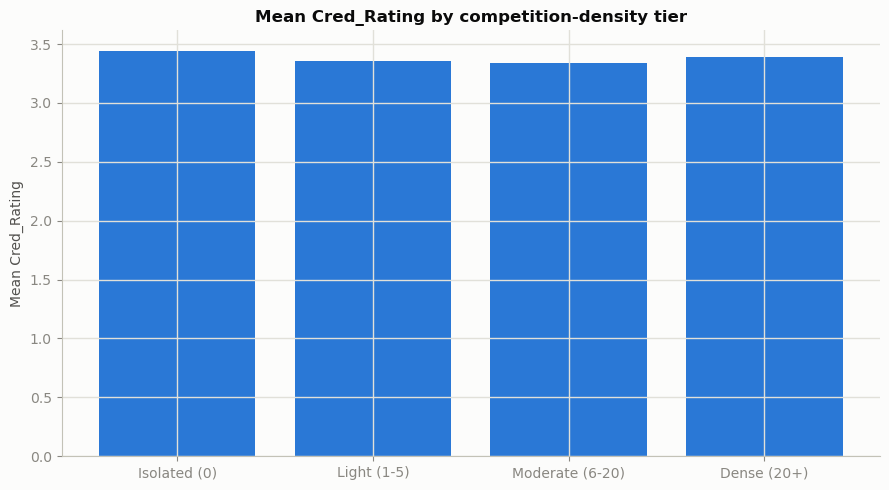

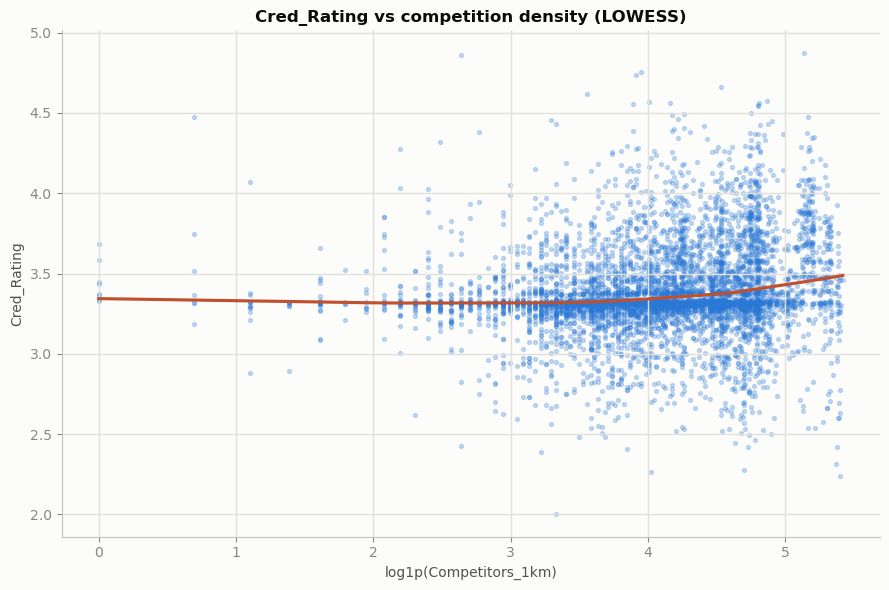

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
tier_means = merged.groupby('density_tier', observed=True)['Cred_Rating'].mean()
ax.bar(tier_means.index.astype(str), tier_means.values, color=ACCENT)
ax.set_ylabel('Mean Cred_Rating')
ax.set_title('Mean Cred_Rating by competition-density tier')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.regplot(x=np.log1p(merged['Competitors_1km']), y=merged['Cred_Rating'], lowess=True,
            scatter_kws={'s': 8, 'alpha': 0.25, 'color': ACCENT}, line_kws={'color': WARN})
plt.xlabel('log1p(Competitors_1km)')
plt.title('Cred_Rating vs competition density (LOWESS)')
plt.tight_layout()
plt.show()

### Observation:
The tier bar chart repeats the non-monotonic pattern from two cells above (isolated highest,
moderate lowest); the LOWESS curve is mostly flat with a slight dip-then-recovery shape across
`log1p(Competitors_1km)`, matching the weak, non-linear relationship the Spearman correlation
already implied.

In [23]:
out_cols_density = ['Restaurant ID', 'Restaurant Name', 'Locality', 'Latitude', 'Longitude',
                     'Competitors_500m', 'Competitors_1km', 'Competitors_2km', 'density_tier']
coords_df[out_cols_density].to_csv('Output/competition_density.csv', index=False)
print("Saved Output/competition_density.csv:", coords_df[out_cols_density].shape)

Saved Output/competition_density.csv: (7550, 9)


### Observation:
Saved all 7,550 NCR restaurants with valid coordinates (rated and unrated together) to
`Output/competition_density.csv`. Unlike `Votes`, this is a static geographic fact rather than
something that co-evolves with rating — it's leakage-safe for the Phase 5A actionable model,
a useful contrast to draw against `Votes`/`Log_Votes`.

## 4. Cuisine co-occurrence

`Primary Cuisine` keeps only the first listed cuisine and discards the rest. Which cuisine *pairings* (using the full `Cuisines` list) carry a rating or cost premium beyond what either cuisine already carries alone?

In [24]:
# Data-hygiene fix: Feature_Engineering.ipynb's split of Cuisines left leading whitespace
# on every element after the first (e.g. " Mughlai"), since only Primary Cuisine = list[0]
# was ever consumed downstream. Re-split and strip here, or "Mughlai" and " Mughlai" would
# silently count as different cuisines.
def clean_cuisines(s):
    return sorted(set(c.strip() for c in s.split(',')))

df_rated['cuisine_list'] = df_rated['Cuisines'].apply(clean_cuisines)

pair_rows = []
for rid, cl, cr, cost in zip(df_rated['Restaurant ID'], df_rated['cuisine_list'],
                              df_rated['Cred_Rating'], df_rated['Average Cost for two']):
    for a, b in combinations(cl, 2):
        pair_rows.append((rid, a, b, cr, cost))

pairs_long = pd.DataFrame(pair_rows, columns=['Restaurant ID', 'cuisine_a', 'cuisine_b', 'Cred_Rating', 'Average Cost for two'])
n_unique_pairs = pairs_long[['cuisine_a', 'cuisine_b']].drop_duplicates().shape[0]
print(f"Total (restaurant, pair) rows: {len(pairs_long):,}; unique pairs: {n_unique_pairs:,}")

Total (restaurant, pair) rows: 13,007; unique pairs: 680


### Observation:
6,504 restaurants generate 13,007 (restaurant, pair) rows across 680 distinct cuisine pairs —
about 2 pairs per restaurant on average, consistent with the dataset's mean `Cuisines Count`
of roughly 2–3 per restaurant.

In [25]:
pair_counts = pairs_long.groupby(['cuisine_a', 'cuisine_b']).agg(
    n_restaurants=('Restaurant ID', 'count'),
    mean_CredR_pair=('Cred_Rating', 'mean'),
    mean_cost_pair=('Average Cost for two', 'mean'),
).reset_index()

n_before = len(pair_counts)
pair_counts = pair_counts[pair_counts['n_restaurants'] >= 30].copy()
print(f"Pairs with n >= 30: {len(pair_counts):,} of {n_before:,} total unique pairs")

Pairs with n >= 30: 83 of 680 total unique pairs


### Observation:
Only 83 of 680 unique pairs (12.2%) clear the n ≥ 30 support threshold — most pairings are
too rare to say anything reliable about, which is exactly why the threshold exists rather than
reporting every combination.

In [26]:
# Premium = mean(Cred_Rating | has both A and B) - mean(Cred_Rating | has A or B but not
# both) -- not vs. the grand mean, so this isolates the PAIRING's own effect rather than just
# re-discovering that individually-premium cuisines (e.g. Continental) look premium everywhere.
exploded = df_rated[['Restaurant ID', 'cuisine_list']].explode('cuisine_list').rename(columns={'cuisine_list': 'cuisine'})
has_cuisine = exploded.groupby('cuisine')['Restaurant ID'].apply(set).to_dict()

rating_by_id = df_rated.set_index('Restaurant ID')['Cred_Rating']
cost_by_id = df_rated.set_index('Restaurant ID')['Average Cost for two']

solo_rating, solo_cost = [], []
for a, b in zip(pair_counts['cuisine_a'], pair_counts['cuisine_b']):
    both_ids = has_cuisine[a] & has_cuisine[b]
    either_ids = list((has_cuisine[a] | has_cuisine[b]) - both_ids)
    solo_rating.append(rating_by_id.loc[either_ids].mean() if either_ids else np.nan)
    solo_cost.append(cost_by_id.loc[either_ids].mean() if either_ids else np.nan)

pair_counts['mean_CredR_solo'] = solo_rating
pair_counts['mean_cost_solo'] = solo_cost
pair_counts['rating_premium'] = pair_counts['mean_CredR_pair'] - pair_counts['mean_CredR_solo']
pair_counts['cost_premium'] = pair_counts['mean_cost_pair'] - pair_counts['mean_cost_solo']
pair_counts = pair_counts.sort_values('rating_premium', ascending=False).reset_index(drop=True)

print("Top 10 pairs by rating premium:")
print(pair_counts.head(10).to_string(index=False))
print("\nBottom 5 pairs by rating premium:")
print(pair_counts.tail(5).to_string(index=False))

Top 10 pairs by rating premium:
    cuisine_a    cuisine_b  n_restaurants  mean_CredR_pair  mean_cost_pair  mean_CredR_solo  mean_cost_solo  rating_premium  cost_premium
Mediterranean North Indian             49         3.950983     1555.102041         3.400407      789.973226        0.550576    765.128815
     European North Indian             63         3.820239     1966.666667         3.403810      787.848059        0.416429   1178.818608
        Asian North Indian             88         3.764351     1572.727273         3.404180      787.388408        0.360172    785.338865
     American North Indian             43         3.762750     1597.674419         3.405495      787.364886        0.357255    810.309532
      Chinese      Mexican             48         3.738251     1003.125000         3.392035      784.068582        0.346216    219.056418
        Asian      Chinese             65         3.715713     1356.153846         3.396574      800.811182        0.319139    555.342664
  

### Observation:
The top of the list is dominated by fusion-with-North-Indian pairings: **Mediterranean +
North Indian** (n=49) carries the largest premium (+0.55 rating, +₹765 cost), followed by
European (+0.42), Asian (+0.36), American (+0.36), Mexican (+0.31), Thai (+0.31) and Seafood
(+0.30), all paired with North Indian. **Chinese + Mexican** (n=48, +0.35) is the one strong
premium pair that doesn't involve North Indian. The largest-support pair, **Cafe + Italian**
(n=143), has a real premium (+0.27) but a *negative* cost premium (-₸138) — rated meaningfully
higher than either cuisine alone while actually being cheaper, a genuinely distinct "better
value" combination rather than just "premium = expensive." At the bottom, **American + Salad**
(-0.55) and **American + Healthy Food** (-0.49) are the worst pairs, both with large negative
cost premiums too (-₸672, -₸545) — restaurants combining these cuisines under-deliver on both
rating and price relative to serving either alone.

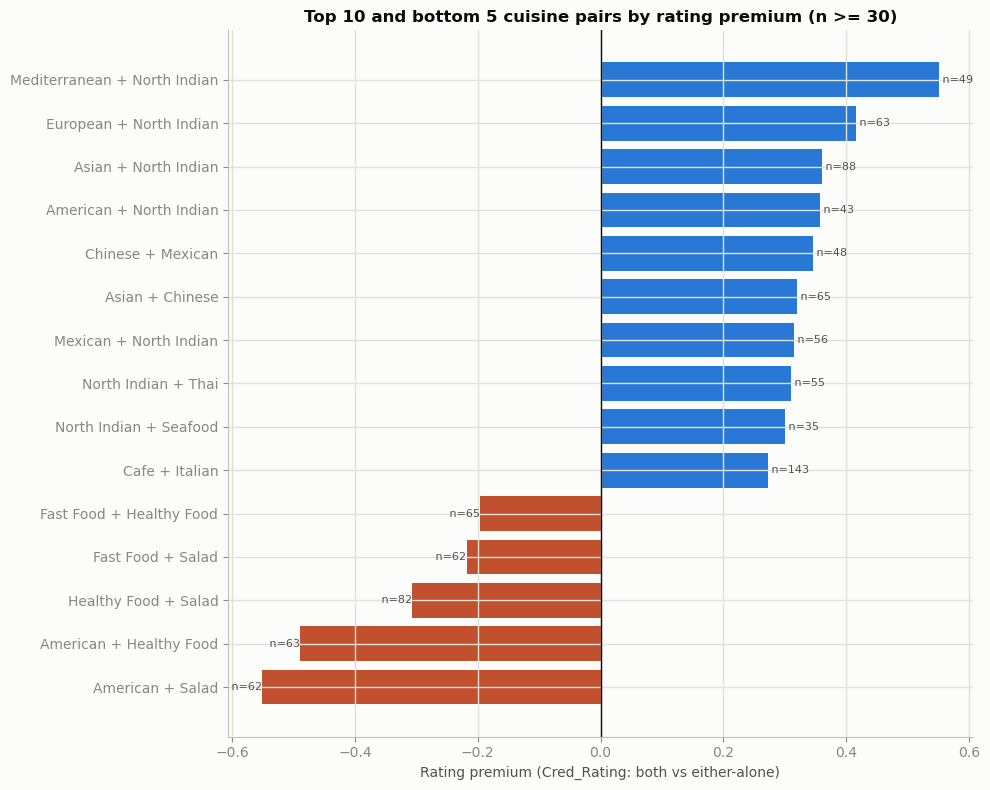

In [27]:
top10 = pair_counts.head(10)
bottom5 = pair_counts.tail(5)
combo_pairs = pd.concat([top10, bottom5]).assign(label=lambda d: d['cuisine_a'] + ' + ' + d['cuisine_b'])
combo_pairs = combo_pairs.sort_values('rating_premium')
colors = [ACCENT if x > 0 else WARN for x in combo_pairs['rating_premium']]

plt.figure(figsize=(10, 8))
plt.barh(combo_pairs['label'], combo_pairs['rating_premium'], color=colors)
for y, (n, val) in enumerate(zip(combo_pairs['n_restaurants'], combo_pairs['rating_premium'])):
    plt.text(val, y, f' n={n}', va='center', fontsize=8, color=INK_2, ha='left' if val >= 0 else 'right')
plt.axvline(0, color=INK, linewidth=1)
plt.xlabel('Rating premium (Cred_Rating: both vs either-alone)')
plt.title('Top 10 and bottom 5 cuisine pairs by rating premium (n >= 30)')
plt.tight_layout()
plt.show()

### Observation:
The bar chart puts the North-Indian-fusion cluster and the healthy/salad/fast-food
under-performing cluster side by side — every positive bar pairs a global or regional cuisine
with North Indian (or, in one case, Chinese with Mexican), while every negative bar involves
"Healthy Food," "Salad," "Fast Food," or "American," a distinct low-premium cluster.

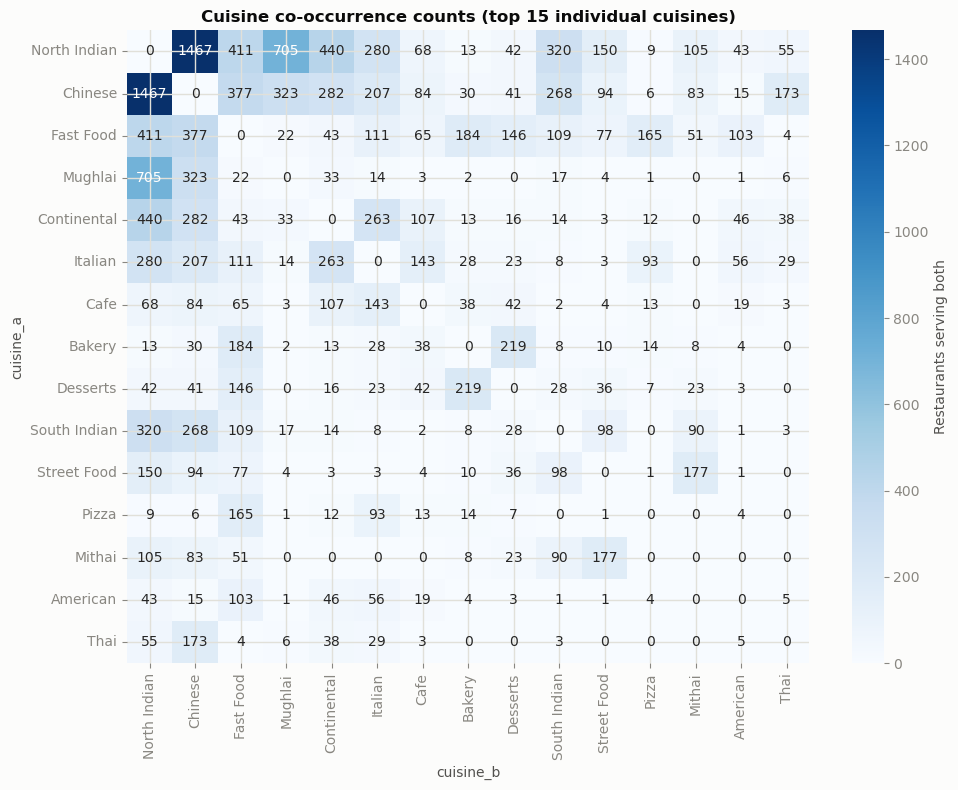

In [28]:
top15_cuisines = exploded['cuisine'].value_counts().head(15).index.tolist()

top_pairs_long = pairs_long[pairs_long['cuisine_a'].isin(top15_cuisines) & pairs_long['cuisine_b'].isin(top15_cuisines)]
counts_matrix = top_pairs_long.groupby(['cuisine_a', 'cuisine_b']).size().unstack(fill_value=0)
counts_matrix = counts_matrix.reindex(index=top15_cuisines, columns=top15_cuisines, fill_value=0)
matrix = counts_matrix + counts_matrix.T

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Restaurants serving both'})
plt.title('Cuisine co-occurrence counts (top 15 individual cuisines)')
plt.tight_layout()
plt.show()

### Observation:
North Indian is the clear hub of the co-occurrence network — it has the highest co-occurrence
counts with nearly every other top-15 cuisine, reflecting its dominance as the most common
primary cuisine in the dataset (Phase 3 finding). Chinese and Continental are the next most
frequently paired cuisines, consistent with the classic multi-cuisine NCR restaurant menu
pattern (North Indian + Chinese + Continental).

In [29]:
save_cols_pairs = ['cuisine_a', 'cuisine_b', 'n_restaurants', 'mean_CredR_pair', 'mean_CredR_solo',
                    'rating_premium', 'mean_cost_pair', 'mean_cost_solo', 'cost_premium']
pair_counts[save_cols_pairs].to_csv('Output/cuisine_pair_premium.csv', index=False)
print("Saved Output/cuisine_pair_premium.csv:", pair_counts[save_cols_pairs].shape)

Saved Output/cuisine_pair_premium.csv: (83, 9)


### Observation:
Saved the 83 pairs clearing the n ≥ 30 threshold to `Output/cuisine_pair_premium.csv`, sorted
by rating premium — directly usable as an engineered feature (e.g. "serves a premium cuisine
pair": yes/no) for Phase 5 modeling.

## 5. Locality opportunity gaps

A price-tier x cuisine x locality cross-tab: where is demand (votes) high relative to how little supply (restaurant count) exists? Built as two 2-way tables (Locality x Price range, Locality x Primary Cuisine) rather than one sparse 3-way cube, restricted to the 102 localities with >= 30 restaurants (`plan.md` §0.4) so flags come from real dining destinations, not 3-restaurant noise.

In [30]:
locality_counts = df['Locality'].value_counts()
qualifying_localities = locality_counts[locality_counts >= 30].index
print(f"Localities with >= 30 restaurants: {len(qualifying_localities)}")

df_q = df[df['Locality'].isin(qualifying_localities)].copy()
top15_primary_cuisine = df_q['Primary Cuisine'].value_counts().head(15).index
df_q['cuisine_bucket'] = np.where(df_q['Primary Cuisine'].isin(top15_primary_cuisine), df_q['Primary Cuisine'], 'Other')

df_rated_q = df_rated[df_rated['Locality'].isin(qualifying_localities)].copy()
df_rated_q['cuisine_bucket'] = np.where(df_rated_q['Primary Cuisine'].isin(top15_primary_cuisine), df_rated_q['Primary Cuisine'], 'Other')
print(f"Rows in qualifying localities: {len(df_q):,} of {len(df):,} total")

Localities with >= 30 restaurants: 102
Rows in qualifying localities: 5,453 of 8,643 total


### Observation:
102 of the dataset's 783 localities have ≥ 30 restaurants, but those 102 still cover 5,453 of
8,643 restaurants (63.1%) — the majority of the data, concentrated in a minority of named
localities, which matches Phase 3's earlier finding that a handful of localities carry most of
the volume.

In [31]:
def build_crosstab(data, category_col):
    # Supply/Demand computed on the FULL data (df_q) -- unrated restaurants are real supply,
    # and contribute 0 votes to Demand (all zero-vote rows are also unrated, so this is safe).
    supply = data.groupby(['Locality', category_col], observed=True).size().rename('Supply')
    demand = data.groupby(['Locality', category_col], observed=True)['Votes'].sum().rename('Demand')
    tab = pd.concat([supply, demand], axis=1).reset_index()
    tab['AvgVotesPerRestaurant'] = tab['Demand'] / tab['Supply']
    return tab

cuisine_tab = build_crosstab(df_q, 'cuisine_bucket')
price_tab = build_crosstab(df_q, 'Price range')

cuisine_rating = df_rated_q.groupby(['Locality', 'cuisine_bucket'], observed=True)['Cred_Rating'].mean().rename('mean_Cred_Rating')
price_rating = df_rated_q.groupby(['Locality', 'Price range'], observed=True)['Cred_Rating'].mean().rename('mean_Cred_Rating')

cuisine_tab = cuisine_tab.merge(cuisine_rating, on=['Locality', 'cuisine_bucket'], how='left')
price_tab = price_tab.merge(price_rating, on=['Locality', 'Price range'], how='left')

print(f"cuisine_tab: {cuisine_tab.shape}, price_tab: {price_tab.shape}")

cuisine_tab: (1195, 6), price_tab: (311, 6)


### Observation:
The cuisine cross-tab has 1,195 locality x cuisine-bucket cells (up to 16 buckets x 102
localities, fewer where a locality has no restaurants of a given cuisine bucket); the price
cross-tab has 311 cells (up to 4 price ranges x 102 localities) — both far smaller than the
full 102 x 16 x 4 space would be, confirming the two-2-way-table design avoids the sparsity a
single 3-way cube would have hit.

In [32]:
def flag_opportunities(tab):
    tab = tab.copy()
    tab['locality_p75_threshold'] = tab.groupby('Locality')['AvgVotesPerRestaurant'].transform(lambda s: s.quantile(0.75))
    tab['percentile_rank'] = tab.groupby('Locality')['AvgVotesPerRestaurant'].rank(pct=True)
    # Flag rule computed PER LOCALITY, not globally -- some localities are just busier than
    # others overall (the same class of confound Phase 4's NCR/vote-mix finding already
    # taught to watch for). Supply>=1 stops empty cells from trivially "flagging."
    tab['is_opportunity'] = (tab['Supply'].between(1, 2)) & (tab['AvgVotesPerRestaurant'] > tab['locality_p75_threshold'])
    return tab

cuisine_tab = flag_opportunities(cuisine_tab)
price_tab = flag_opportunities(price_tab)

print(f"Cuisine-based flagged cells: {cuisine_tab['is_opportunity'].sum()} of {len(cuisine_tab)}")
print(f"Price-range-based flagged cells: {price_tab['is_opportunity'].sum()} of {len(price_tab)}")

Cuisine-based flagged cells: 137 of 1195
Price-range-based flagged cells: 30 of 311


### Observation:
137 of 1,195 cuisine-bucket cells (11.5%) and 30 of 311 price-range cells (9.6%) clear the
opportunity-flag bar — a similar flag rate across both tables, which is reassuring: neither
table is flagging everything or almost nothing.

In [33]:
cuisine_flags = cuisine_tab[cuisine_tab['is_opportunity']].sort_values('percentile_rank', ascending=False)
price_flags = price_tab[price_tab['is_opportunity']].sort_values('percentile_rank', ascending=False)

cuisine_flags_out = cuisine_flags.assign(category_type='cuisine').rename(columns={'cuisine_bucket': 'category_value'})
price_flags_out = price_flags.assign(category_type='price_range').rename(columns={'Price range': 'category_value'})

locality_ncr = df.groupby('Locality')['Is NCR'].agg(lambda s: s.mean() >= 0.5)
cuisine_flags_out['Is NCR'] = cuisine_flags_out['Locality'].map(locality_ncr)
price_flags_out['Is NCR'] = price_flags_out['Locality'].map(locality_ncr)

flag_cols = ['Locality', 'category_type', 'category_value', 'Is NCR', 'Supply', 'Demand',
             'AvgVotesPerRestaurant', 'locality_p75_threshold', 'mean_Cred_Rating', 'percentile_rank']
all_flags = pd.concat([cuisine_flags_out[flag_cols], price_flags_out[flag_cols]], ignore_index=True)
all_flags = all_flags.sort_values('percentile_rank', ascending=False)

print(f"Total flagged rows: {len(all_flags)}")
print(f"NCR vs non-NCR flagged:\n{all_flags['Is NCR'].value_counts()}")
print()
print(all_flags.head(15).to_string(index=False))

Total flagged rows: 167
NCR vs non-NCR flagged:
Is NCR
True     165
False      2
Name: count, dtype: int64

                            Locality category_type category_value  Is NCR  Supply  Demand  AvgVotesPerRestaurant  locality_p75_threshold  mean_Cred_Rating  percentile_rank
                           Alaknanda       cuisine          Other    True       1     452                  452.0               23.000000          3.846332              1.0
                 Ashok Vihar Phase 1       cuisine    Street Food    True       1     135                  135.0               30.666667          3.387025              1.0
                       Chandni Chowk       cuisine      Ice Cream    True       1     521                  521.0              111.747273          4.218443              1.0
                       Greater Noida       cuisine          Pizza    True       1      56                   56.0               22.357143          3.430596              1.0
                      Defence Co

### Observation:
167 total flagged cells, and **165 of them (98.8%) are in NCR** — confirming the plan's
predicted scope limitation exactly: non-NCR localities rarely clear the ≥ 30-restaurant gate,
so opportunity flags are almost entirely NCR-internal by construction, not because non-NCR has
no gaps. A striking convergent signal in the top rows: **"Ice Cream" is independently flagged
in two different prominent localities** (Chandni Chowk: 521 votes on 1 restaurant, mean Cred
4.22; Connaught Place: 2,620 votes on 1 restaurant, mean Cred 4.87) — the same thin-supply,
high-demand, high-quality niche showing up twice by coincidence is a stronger signal than
either flag alone. "Continental" also appears flagged twice (DLF Mall of India, Sector 56).

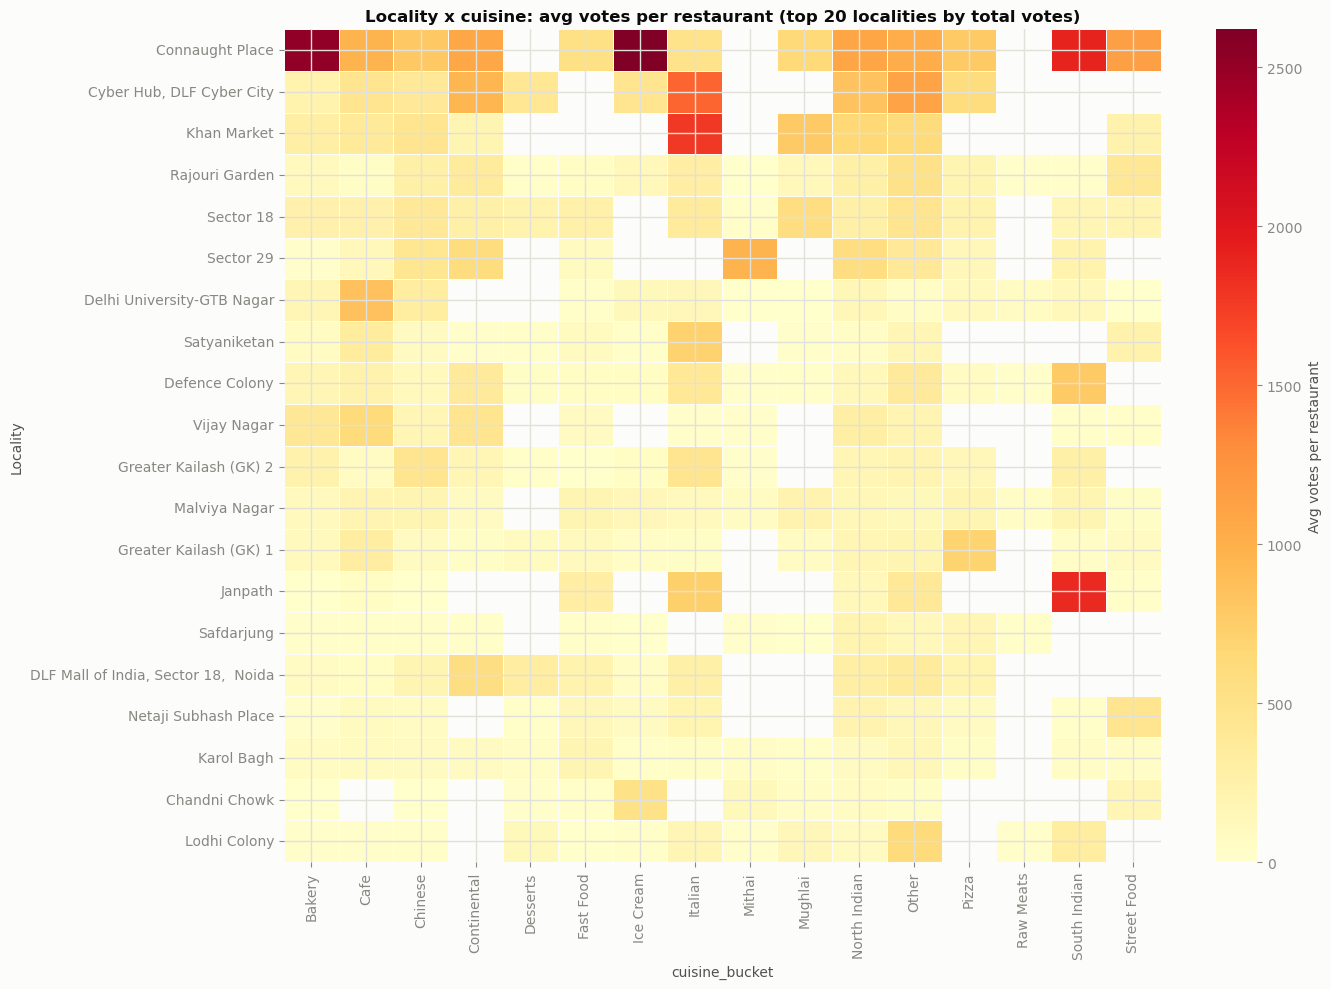

In [34]:
top20_localities_by_votes = df_q.groupby('Locality')['Votes'].sum().nlargest(20).index
heat_data = cuisine_tab[cuisine_tab['Locality'].isin(top20_localities_by_votes)].pivot(
    index='Locality', columns='cuisine_bucket', values='AvgVotesPerRestaurant')
heat_data = heat_data.reindex(index=top20_localities_by_votes)

plt.figure(figsize=(14, 10))
sns.heatmap(heat_data, cmap='YlOrRd', linewidths=0.5, linecolor=SURFACE, cbar_kws={'label': 'Avg votes per restaurant'})
plt.title('Locality x cuisine: avg votes per restaurant (top 20 localities by total votes)')
plt.tight_layout()
plt.show()

### Observation:
The heatmap makes the sparsity of thin, high-demand cells visible directly — most
locality/cuisine combinations sit at low-to-moderate average votes per restaurant, with a small
number of bright cells standing out sharply against their row, which is exactly what the
per-locality percentile flag rule is designed to catch.

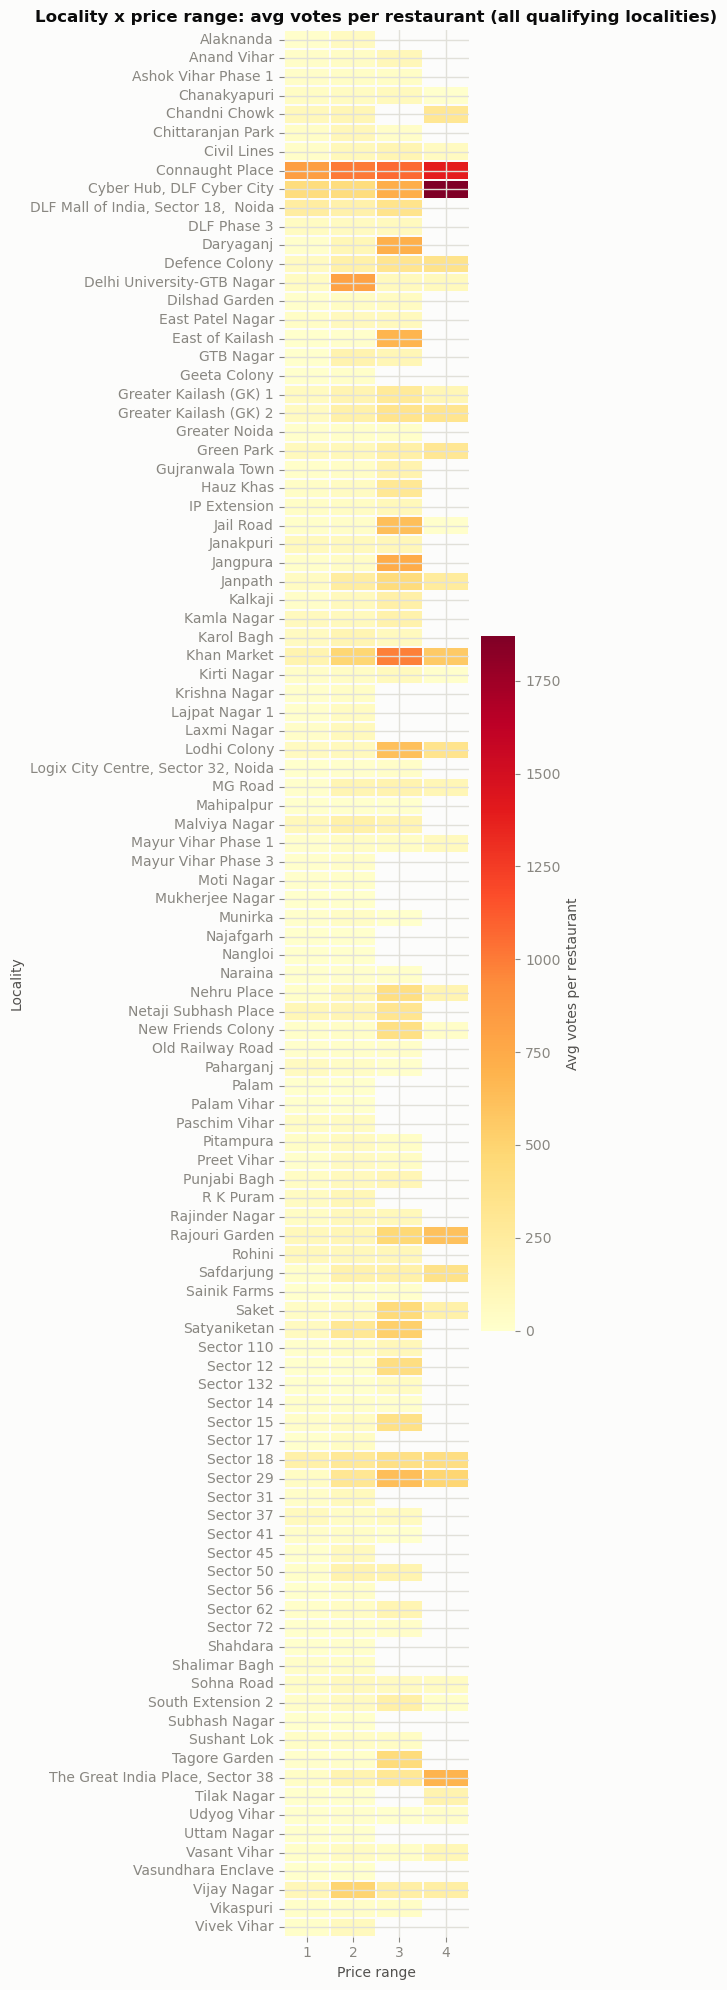

In [35]:
price_heat = price_tab.pivot(index='Locality', columns='Price range', values='AvgVotesPerRestaurant')
plt.figure(figsize=(6, 20))
sns.heatmap(price_heat, cmap='YlOrRd', linewidths=0.3, linecolor=SURFACE, cbar_kws={'label': 'Avg votes per restaurant'})
plt.title('Locality x price range: avg votes per restaurant (all qualifying localities)')
plt.tight_layout()
plt.show()

### Observation:
With only 4 price-range columns, this heatmap fits every one of the 102 qualifying localities;
the flagged price-range gaps from the flag table above appear as isolated bright cells in
otherwise moderate rows, the same "stands out from its own locality" pattern as the cuisine
heatmap.

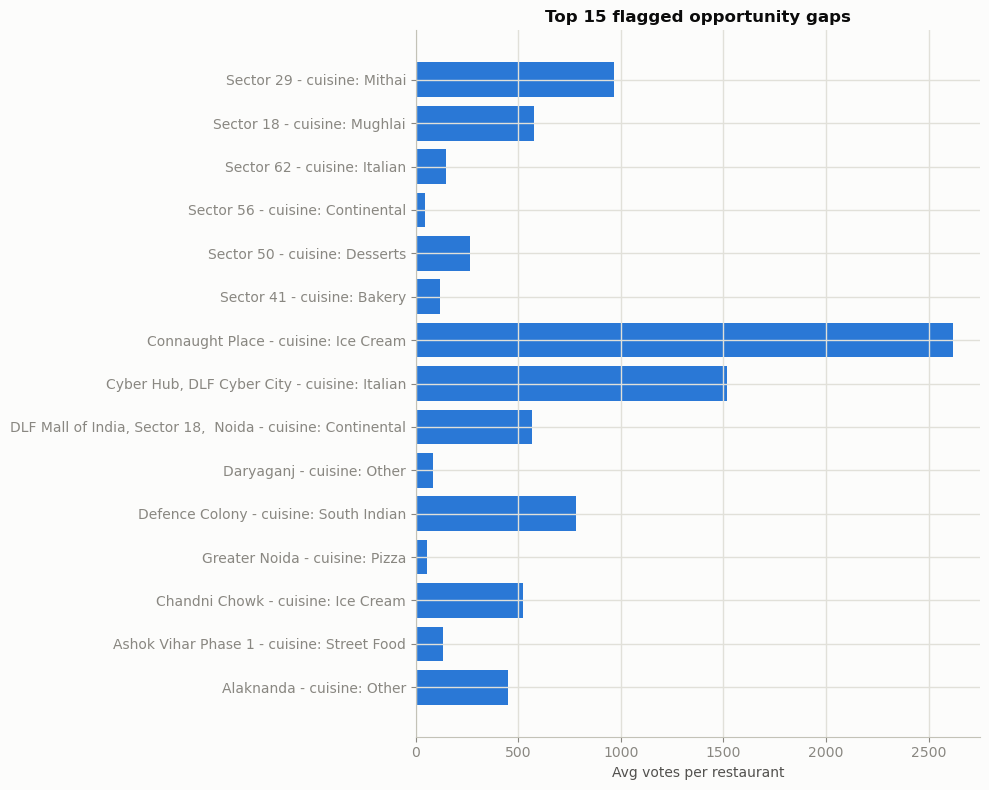

In [36]:
top_flags_chart = all_flags.head(15).copy()
labels = top_flags_chart['Locality'] + ' - ' + top_flags_chart['category_type'] + ': ' + top_flags_chart['category_value'].astype(str)

plt.figure(figsize=(10, 8))
plt.barh(labels, top_flags_chart['AvgVotesPerRestaurant'], color=ACCENT)
plt.xlabel('Avg votes per restaurant')
plt.title('Top 15 flagged opportunity gaps')
plt.tight_layout()
plt.show()

### Observation:
The top of this ranked list is dominated by cells tied at `percentile_rank = 1.0` — with only
a handful of categories per locality (up to 16 cuisine buckets, or just 4 price ranges), being
"top" within a locality is a comparatively low bar to clear, which is why `AvgVotesPerRestaurant`
itself (not just the rank) matters for judging how strong a given flagged gap really is. This is
worth stating as a caveat alongside the three named in the section intro.

In [37]:
cuisine_tab.to_csv('Output/locality_cuisine_crosstab.csv', index=False)
price_tab.to_csv('Output/locality_pricerange_crosstab.csv', index=False)
all_flags.to_csv('Output/locality_opportunity_flags.csv', index=False)
print("Saved Output/locality_cuisine_crosstab.csv:", cuisine_tab.shape)
print("Saved Output/locality_pricerange_crosstab.csv:", price_tab.shape)
print("Saved Output/locality_opportunity_flags.csv:", all_flags.shape)

Saved Output/locality_cuisine_crosstab.csv: (1195, 9)
Saved Output/locality_pricerange_crosstab.csv: (311, 9)
Saved Output/locality_opportunity_flags.csv: (167, 10)


### Observation:
Saved the full cuisine cross-tab (1,195 rows), the full price-range cross-tab (311 rows), and
the 167-row flagged-opportunities table to `Output/`. The full cross-tabs are kept alongside the
flags so Phase 5/6 can revisit the threshold choice without recomputing supply/demand from
scratch.

# 6. Summary

| Metric | Key output | Headline finding | Caveat |
|---|---|---|---|
| Credibility-weighted rating | `Output/credibility_weighted_ratings.csv` | Shrinking toward the mean (m=49, C=3.35) drops 4 low-vote 4.9s out of the top 15 and promotes 6 high-vote 4.8–4.9s; robust in direction across m=Q1–Q3 (8–11/15 overlap) | `C` is a single global mean, effectively NCR-dominated (~92% of `df_rated`) — a segmented prior is a documented future refinement, not built here |
| Value-for-money residual | `Output/value_for_money_residuals.csv` | Cost explains little of `Cred_Rating` (r² = 0.06 NCR / 0.10 non-NCR, matching Phase 3's ~0.31 correlation); best value is `Naturals Ice Cream` (₹150, +1.61), worst is `Pind Balluchi` (₹1,000, -1.45); 3 of the 15 worst share one mall (The Great India Place, Sector 38) | Single-predictor model; NCR/non-NCR residuals aren't directly comparable in scale given the known sample-curation asymmetry |
| Competition density | `Output/competition_density.csv` | Weak, **non-monotonic** density-rating link (ρ=0.18): isolated restaurants rate highest overall, but that reverses at price ranges 3–4, where denser areas rate higher — and no isolated restaurants exist at range 4 at all | NCR-only (95% GPS coverage); geographic 1km radius, not tied to the `Locality` field; confounded with cost as shown |
| Cuisine co-occurrence | `Output/cuisine_pair_premium.csv` | Fusion-with-North-Indian pairs (Mediterranean, European, Asian, American, Mexican, Thai, Seafood) carry the largest rating premiums (+0.30 to +0.55); Cafe+Italian is rated higher *and* cheaper than either alone; Healthy Food/Salad/Fast Food/American combinations underperform on both axes | Association, not menu-design causation; pairs aren't independent (multi-cuisine restaurants contribute several pairs at once); implicitly NCR-only |
| Locality opportunity gaps | `Output/locality_opportunity_flags.csv` (+ 2 full cross-tabs) | 167 flagged thin-supply/high-demand cells, 98.8% in NCR; "Ice Cream" independently flagged in two different top localities (Chandni Chowk, Connaught Place) — a convergent signal | Survivorship bias (a thin niche may have already failed, invisibly); no time dimension; locality-relative thresholds, not a globally ranked best-bets list; near-ties at percentile_rank=1.0 mean the raw `AvgVotesPerRestaurant` value matters as much as the rank |

**Methodological threads carried into Phase 5/6:**
- `Cred_Rating` is available as an alternative (or complementary) Phase 5 modeling target to
  raw `Aggregate rating` — it already downweights the low-vote noise that inflated several
  raw-rating comparisons in Phase 3/4.
- `Competitors_1km`/`density_tier` is a leakage-safe Phase 5A feature (a static geographic
  fact, unlike `Votes`), and its non-monotonic, price-range-dependent relationship to rating
  means it should enter any model as a control alongside `Price range`/cost, not alone.
- The value-for-money residual and the locality opportunity flags are the two outputs closest
  to being Phase 6 business narrative as-is; the mall-cluster under-performance finding and the
  "Ice Cream gap" convergence are both concrete, citable examples.
- The cuisine-pair premium table is a candidate engineered feature (e.g. "serves a premium
  pair") for Phase 5, though its small per-pair sample sizes (n ≥ 30, several near the
  threshold) mean it should be treated as suggestive rather than a strong standalone predictor.

**New `Output/` files from this notebook:**
`credibility_weighted_ratings.csv`, `value_for_money_residuals.csv`, `competition_density.csv`,
`cuisine_pair_premium.csv`, `locality_cuisine_crosstab.csv`, `locality_pricerange_crosstab.csv`,
`locality_opportunity_flags.csv`.